<a href="https://colab.research.google.com/github/sanjanabalan84-glitch/salary-prediction/blob/main/FINAL%20PROJECT%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

In [ ]:
df=pd.read_csv('/content/indian-job-market-dataset-2025.csv',encoding='latin1', on_bad_lines='skip')
df.head()

,title,jobId,currency,jobUploaded,companyName,tagsAndSkills,experience,salary,location,companyId,ReviewsCount,AggregateRating,jobDescription,minimumSalary,maximumSalary,minimumExperience,maximumExperience
0,Sr. HR Recruiter (NON IT),270925008041,INR,6 Days Ago,Orion,"Communication,Manpower,Staffing,Convincing Pow...",2-4 Yrs,2-4 Lacs PA,Kolkata(Chinar Park),645563,NaN,NaN,Preferred candidate profile . .,200000.0,400000.0,2.0,4.0
1,Fire And Safety Officer,270925007584,INR,6 Days Ago,"Apollo Hospitals International Limited, Ahmedabad","Safety Officer Activities,Fire Protection,Fire...",6-11 Yrs,3-5 Lacs PA,"Gandhinagar, Ahmedabad",14072,5162.0,4.0,"Ensure active Fire Protection System,such as F...",300000.0,500000.0,6.0,11.0
2,Opening For Performance Marketing - Chennai,270925007492,INR,6 Days Ago,TVS Credit Services Ltd,"Performance Marketing,User Acquisition,growth ...",12-18 Yrs,Not disclosed,Chennai,1324750,2892.0,4.2,MBA Marketing (preferred Tier II or III B- Sch...,0.0,0.0,12.0,18.0
3,Medical Billing Executive,270925007443,INR,6 Days Ago,GNR Global Services,"Fluent English,Spoken English,Good English Com...",0-3 Yrs,"70,000-2 Lacs PA","Mohali, Chandigarh, Kharar, Zirakpur",123804403,NaN,NaN,Job Title-Medical Billing Executive\nLocation-...,70000.0,200000.0,0.0,3.0
4,Senior Group Product Manager - CNS Therapy,270925007430,INR,6 Days Ago,Cadila Pharmaceuticals,"Product Marketing,CNS,Product Management,Nephr...",5-10 Yrs,8-18 Lacs PA,Ahmedabad,14957,2134.0,3.4,Principal Tasks & Responsibilities : (Please w...,800000.0,1800000.0,5.0,10.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97929 entries, 0 to 97928
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              97929 non-null  object 
 1   jobId              97929 non-null  int64  
 2   currency           97929 non-null  object 
 3   jobUploaded        97929 non-null  object 
 4   companyName        97925 non-null  object 
 5   tagsAndSkills      97358 non-null  object 
 6   experience         95824 non-null  object 
 7   salary             97929 non-null  object 
 8   location           97929 non-null  object 
 9   companyId          97929 non-null  int64  
 10  ReviewsCount       62677 non-null  float64
 11  AggregateRating    62677 non-null  float64
 12  jobDescription     97929 non-null  object 
 13  minimumSalary      97358 non-null  float64
 14  maximumSalary      97358 non-null  float64
 15  minimumExperience  97358 non-null  float64
 16  maximumExperience  973

In [ ]:
df.describe()

,jobId,companyId,ReviewsCount,AggregateRating,minimumSalary,maximumSalary,minimumExperience,maximumExperience
count,9.792900e+04,9.792900e+04,62677.000000,62677.000000,9.735800e+04,9.735800e+04,97358.000000,97358.000000
mean,2.069854e+11,2.784642e+07,14662.590264,3.679048,1.983092e+05,3.186096e+05,3.957744,7.732647
std,9.987860e+10,4.979184e+07,24744.514682,0.484096,5.640765e+05,8.417336e+05,3.581196,4.500161
min,1.012500e+10,3.000000e+00,2.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,1.808250e+11,2.339390e+05,65.000000,3.500000,0.000000e+00,0.000000e+00,1.000000,5.000000
50%,2.508250e+11,2.892790e+06,962.000000,3.700000,0.000000e+00,0.000000e+00,3.000000,7.000000
75%,2.808250e+11,6.398332e+06,12826.000000,3.900000,2.000000e+05,3.750000e+05,5.000000,10.000000
max,3.112240e+11,1.251422e+08,104449.000000,5.000000,7.000000e+07,9.500000e+07,30.000000,35.000000


In [ ]:
df.isnull().sum()

,0
title,0
jobId,0
currency,0
jobUploaded,0
companyName,4
tagsAndSkills,571
experience,2105
salary,0
location,0
companyId,0


In [ ]:
df.shape

(97929, 17)

In [ ]:
# 3. Handle the Target (minimumSalary)
# If the salary is 0 or NaN, we cannot use it for prediction.
# We filter the 'df' to keep only rows with a valid salary.
df = df[df['minimumSalary'] > 0].copy()

In [ ]:
df['average experience']=(df['minimumExperience']+df['maximumExperience'])/2
df['average salary']=(df['minimumSalary']+df['maximumSalary'])/2

In [ ]:
df=df.drop(['minimumSalary','maximumSalary','minimumExperience','maximumExperience','experience','salary','jobDescription','jobId','currency','jobUploaded','companyId','location'], axis=1, errors='ignore')
df.head()

,title,companyName,tagsAndSkills,ReviewsCount,AggregateRating,average experience,average salary
0,Sr. HR Recruiter (NON IT),Orion,"Communication,Manpower,Staffing,Convincing Pow...",NaN,NaN,3.0,300000.0
1,Fire And Safety Officer,"Apollo Hospitals International Limited, Ahmedabad","Safety Officer Activities,Fire Protection,Fire...",5162.0,4.0,8.5,400000.0
3,Medical Billing Executive,GNR Global Services,"Fluent English,Spoken English,Good English Com...",NaN,NaN,1.5,135000.0
4,Senior Group Product Manager - CNS Therapy,Cadila Pharmaceuticals,"Product Marketing,CNS,Product Management,Nephr...",2134.0,3.4,7.5,1300000.0
5,Senior Accountant,Vedaant Techno Art,"Tds Filing,ITR,Gst Filing,Balance Sheet Finali...",NaN,NaN,12.5,475000.0


In [ ]:
df['company_clean'] = df['companyName'].str.split(',').str[0].str.split(' - ').str[0].str.strip(); df = df.drop('companyName', axis=1)

In [ ]:
df.head()

,title,tagsAndSkills,ReviewsCount,AggregateRating,average experience,average salary,company_clean
0,Sr. HR Recruiter (NON IT),"Communication,Manpower,Staffing,Convincing Pow...",NaN,NaN,3.0,300000.0,Orion
1,Fire And Safety Officer,"Safety Officer Activities,Fire Protection,Fire...",5162.0,4.0,8.5,400000.0,Apollo Hospitals International Limited
3,Medical Billing Executive,"Fluent English,Spoken English,Good English Com...",NaN,NaN,1.5,135000.0,GNR Global Services
4,Senior Group Product Manager - CNS Therapy,"Product Marketing,CNS,Product Management,Nephr...",2134.0,3.4,7.5,1300000.0,Cadila Pharmaceuticals
5,Senior Accountant,"Tds Filing,ITR,Gst Filing,Balance Sheet Finali...",NaN,NaN,12.5,475000.0,Vedaant Techno Art


In [ ]:
df['tagsAndSkills'].nunique()

29499

In [ ]:
imputer = SimpleImputer(strategy='median')
df[['ReviewsCount', 'AggregateRating']] = imputer.fit_transform(df[['ReviewsCount', 'AggregateRating']])

In [ ]:
df['company_clean'] = df['company_clean'].fillna('unknown')
df['company_freq'] = df['company_clean'].map(df['company_clean'].value_counts())

Text(0, 0.5, 'Frequency')

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


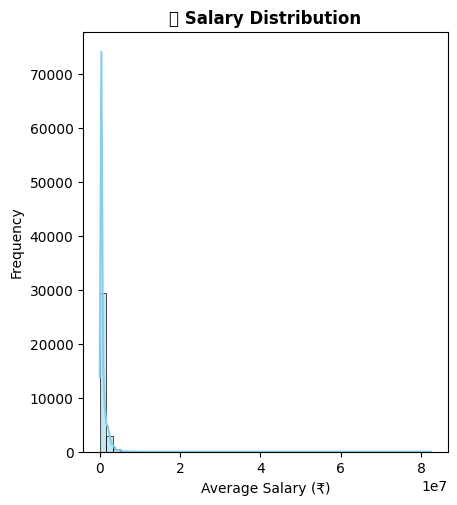

In [ ]:
fig = plt.figure(figsize=(16, 12))
# 1. Salary Distribution
ax1 = fig.add_subplot(2, 3, 1)
sns.histplot(df['average salary'], bins=50, kde=True, ax=ax1, color='skyblue')
ax1.set_title('💰 Salary Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Average Salary (₹)')
ax1.set_ylabel('Frequency')



In [ ]:
df = df[df['average salary'] > 0]
# Remove salary outliers
q1 = df['average salary'].quantile(0.01)
q99 = df['average salary'].quantile(0.99)

df = df[(df['average salary'] >= q1) & (df['average salary'] <= q99)]

In [ ]:
df['title'] = df['title'].str.split(',').str[0].str.split(' - ',).str[0].str.strip()

In [ ]:
df.head()

,title,tagsAndSkills,ReviewsCount,AggregateRating,average experience,average salary,company_clean,company_freq
0,Sr. HR Recruiter (NON IT),"Communication,Manpower,Staffing,Convincing Pow...",87.0,3.7,3.0,300000.0,Orion,8
1,Fire And Safety Officer,"Safety Officer Activities,Fire Protection,Fire...",5162.0,4.0,8.5,400000.0,Apollo Hospitals International Limited,1
3,Medical Billing Executive,"Fluent English,Spoken English,Good English Com...",87.0,3.7,1.5,135000.0,GNR Global Services,14
4,Senior Group Product Manager,"Product Marketing,CNS,Product Management,Nephr...",2134.0,3.4,7.5,1300000.0,Cadila Pharmaceuticals,12
5,Senior Accountant,"Tds Filing,ITR,Gst Filing,Balance Sheet Finali...",87.0,3.7,12.5,475000.0,Vedaant Techno Art,2


In [ ]:
df.isnull().sum()

,0
title,0
tagsAndSkills,0
ReviewsCount,0
AggregateRating,0
average experience,0
average salary,0
company_clean,0
company_freq,0


In [ ]:
df['title'].nunique()

17909

In [ ]:
df['title_target_enc'] = df.groupby('title')['average salary'].transform('mean')  #target encoding

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['title_target_enc'] = scaler.fit_transform(df[['title_target_enc']])

In [ ]:
df.drop(['title'],axis=1,inplace=True)

In [ ]:
df.head()

,tagsAndSkills,ReviewsCount,AggregateRating,average experience,average salary,company_clean,company_freq,title_target_enc
0,"Communication,Manpower,Staffing,Convincing Pow...",87.0,3.7,3.0,300000.0,Orion,8,-0.609279
1,"Safety Officer Activities,Fire Protection,Fire...",5162.0,4.0,8.5,400000.0,Apollo Hospitals International Limited,1,-0.539642
3,"Fluent English,Spoken English,Good English Com...",87.0,3.7,1.5,135000.0,GNR Global Services,14,-0.833975
4,"Product Marketing,CNS,Product Management,Nephr...",2134.0,3.4,7.5,1300000.0,Cadila Pharmaceuticals,12,0.876310
5,"Tds Filing,ITR,Gst Filing,Balance Sheet Finali...",87.0,3.7,12.5,475000.0,Vedaant Techno Art,2,-0.370570


In [ ]:
df.drop(['company_clean'],axis=1,inplace=True, errors='ignore')

In [ ]:
df.head()

,tagsAndSkills,ReviewsCount,AggregateRating,average experience,average salary,company_freq,title_target_enc
0,"Communication,Manpower,Staffing,Convincing Pow...",87.0,3.7,3.0,300000.0,8,-0.609279
1,"Safety Officer Activities,Fire Protection,Fire...",5162.0,4.0,8.5,400000.0,1,-0.539642
3,"Fluent English,Spoken English,Good English Com...",87.0,3.7,1.5,135000.0,14,-0.833975
4,"Product Marketing,CNS,Product Management,Nephr...",2134.0,3.4,7.5,1300000.0,12,0.876310
5,"Tds Filing,ITR,Gst Filing,Balance Sheet Finali...",87.0,3.7,12.5,475000.0,2,-0.370570


In [ ]:
from sklearn.model_selection import train_test_split

# Transform target
y = np.log1p(df['average salary'])   # log(1 + salary) to avoid issues with 0

X = df.drop(columns=['average salary'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model.fit(X_train, y_train)

# Predict in log space
# y_pred_log = model.predict(X_test)

# # Convert back to original salary scale
# y_pred = np.expm1(y_pred_log)   # inverse of log1p

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (26115, 6)
y_train shape: (26115,)


In [ ]:
df['tagsAndSkills'].nunique()

28947

In [ ]:
# Step 1: Handle missing values and prepare the data
X_train['tagsAndSkills'] = X_train['tagsAndSkills'].fillna('').astype(str)
X_test['tagsAndSkills'] = X_test['tagsAndSkills'].fillna('').astype(str)


In [ ]:
# Step 2: Split into lists (keeping as lists for MultiLabelBinarizer)
X_train['tagsAndSkills'] = X_train['tagsAndSkills'].str.split(',').apply(lambda x: [tag.strip().lower() for tag in x if tag.strip()])
X_test['tagsAndSkills'] = X_test['tagsAndSkills'].str.split(',').apply(lambda x: [tag.strip().lower() for tag in x if tag.strip()])


In [ ]:
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Processing {X_train['tagsAndSkills'].explode().nunique()} unique tags...")

Training samples: 26115
Test samples: 6529
Processing 23160 unique tags...


In [ ]:
# Step 3: MultiLabel Binarization (with sparse matrix for memory efficiency)
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer(sparse_output=True)  # Use sparse matrix to save memory

print("Fitting MultiLabelBinarizer...")
X_train_tags = mlb.fit_transform(X_train['tagsAndSkills'])
X_test_tags = mlb.transform(X_test['tagsAndSkills'])

print(f"Number of unique tags: {len(mlb.classes_)}")


Fitting MultiLabelBinarizer...
Number of unique tags: 23160


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['1. good spoken and written english and tamil', '1040s', '1099 & us visas. excellent sourcing & negotiation skills required.', '1099 recruitment', '11th', '12+ years in it sales enterprise sales global market', '12t', '17025', '2. medical content writing', '2025 pass out', '21 cfr 820', '24.7 ai', '247.ai', '2d programming', '3 to 6 years exp. in mfg industry', '3-4 yrs. exp. on the same level', '3-axis', '360 degree marketing', '3b', '3d aoi programming', '3d maya', '3d printing', '3d texturing', '5-axis painting systems', '5g architecture', '5g core', '5s kaizen', '765kv', '8d report', 'a license', 'a+ content', 'a+ listing', 'aatp', 'abap debugging', 'abap workbench', 'ability to coordinate', 'ability to work in shifts', 'ability to work independently.', 'abroad', 'academic', 'academic counselor', 'academic director', 'academic excellence', 'account maintenance', 'accountant/

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


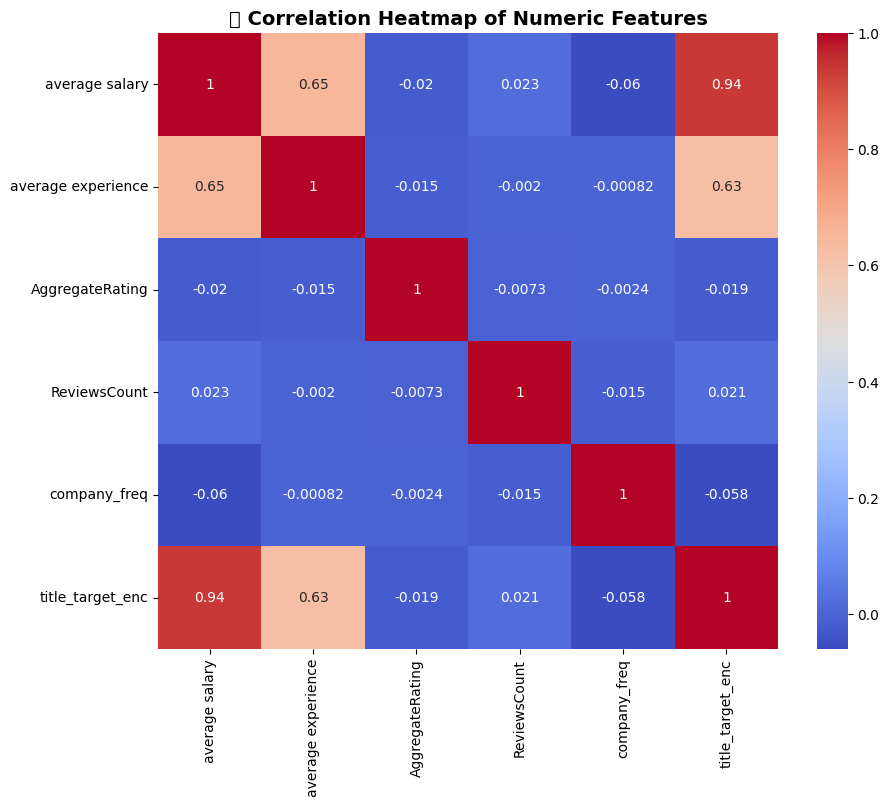

In [ ]:
# Create a single figure for just the correlation heatmap
plt.figure(figsize=(10, 8))
numeric_cols = ['average salary', 'average experience', 'AggregateRating',
                'ReviewsCount', 'company_freq', 'title_target_enc']
corr = df[numeric_cols].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')     # Color scheme (red=positive, blue=negative)
plt.title('📊 Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.show()


In [ ]:
# Memory-efficient approach for large feature sets
from sklearn.decomposition import TruncatedSVD  # Works directly with sparse matrices


In [ ]:
#Step 4: Use TruncatedSVD instead of PCA (works with sparse matrices)
print("Applying TruncatedSVD for dimensionality reduction...")
# Ensure n_components is not greater than the number of features
n_components = min(500, X_train_tags.shape[1]) if X_train_tags.shape[1] > 0 else 1 # Ensure at least 1 if possible
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_train_tags_reduced = svd.fit_transform(X_train_tags)  # Works directly with sparse
X_test_tags_reduced = svd.transform(X_test_tags)

Applying TruncatedSVD for dimensionality reduction...


In [ ]:
# Step 5: Scale the reduced features
scaler_svd = StandardScaler() # Using a new scaler
X_train_tags_scaled = scaler_svd.fit_transform(X_train_tags_reduced)
X_test_tags_scaled = scaler_svd.transform(X_test_tags_reduced)

print(f"Reduced from {X_train_tags.shape[1]} to {X_train_tags_scaled.shape[1]} features")
print(f"Explained variance: {svd.explained_variance_ratio_.sum():.2%}")


Reduced from 23160 to 500 features
Explained variance: 53.41%


In [ ]:
# Step 6: Create final DataFrames
svd_columns = [f'tag_svd_{i+1}' for i in range(X_train_tags_scaled.shape[1])]
X_train_svd_df = pd.DataFrame(X_train_tags_scaled,columns=svd_columns,index=X_train.index)
X_test_svd_df = pd.DataFrame(X_test_tags_scaled,columns=svd_columns,index=X_test.index)

In [ ]:
# Defensive check: Ensure 'title' column is dropped from X_train and X_test if it somehow still exists
if 'title' in X_train.columns:
    print("Warning: 'title' column found in X_train. Dropping it defensively.")
    X_train = X_train.drop('title', axis=1)
if 'title' in X_test.columns:
    print("Warning: 'title' column found in X_test. Dropping it defensively.")
    X_test = X_test.drop('title', axis=1)

# Combine with original data (X_train and X_test now contain title_target_enc and no string 'title')
X_train_final = pd.concat([X_train.drop('tagsAndSkills', axis=1), X_train_svd_df], axis=1)
X_test_final = pd.concat([X_test.drop('tagsAndSkills', axis=1), X_test_svd_df], axis=1)

In [ ]:
X_train_final.head()

,ReviewsCount,AggregateRating,average experience,company_freq,title_target_enc,tag_svd_1,tag_svd_2,tag_svd_3,tag_svd_4,tag_svd_5,...,tag_svd_491,tag_svd_492,tag_svd_493,tag_svd_494,tag_svd_495,tag_svd_496,tag_svd_497,tag_svd_498,tag_svd_499,tag_svd_500
969,10.0,3.4,7.5,3,-0.535000,-0.664279,-0.074122,-0.087438,-0.005732,-0.145869,...,-0.109042,0.838705,0.312930,0.938396,-0.357178,-0.179380,-0.010747,-0.232411,0.680687,-0.239376
67122,87.0,3.7,4.5,2,-0.474073,1.412045,0.101074,1.414818,4.135255,-1.654860,...,0.364983,0.243058,-0.495045,-0.620774,0.214199,-0.116333,0.071218,-0.118691,-0.159296,0.169709
56417,6.0,3.1,8.5,4,0.002288,-0.674007,-0.087020,-0.091290,0.029146,-0.234272,...,-2.837462,1.286850,-2.242176,-4.401125,-0.131953,-3.719011,0.827769,3.249461,0.869765,-7.095085
1543,87.0,3.7,7.5,7,1.916222,-0.711355,-0.077514,-0.130696,-0.016778,-0.267823,...,0.077572,-0.034915,0.118558,-0.020333,-0.023157,-0.268398,-0.101718,-0.130940,-0.189460,-0.043258
69615,87.0,3.7,15.0,288,2.659017,-0.690415,-0.089546,-0.096420,0.014210,1.177219,...,-0.129281,-0.098164,0.319171,-0.256309,-0.299783,-0.108511,0.008245,0.047949,-0.472935,0.229040


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_final, y_train)
print("Model trained!")

Model trained!


In [ ]:
#3.Make predictions
y_pred_train_log = rf_model.predict(X_train_final)
y_pred_test_log = rf_model.predict(X_test_final)


In [ ]:
#4.Convert to original scale
y_pred_train_original = np.exp(y_pred_train_log)
y_pred_test_original = np.exp(y_pred_test_log)
y_train_original = np.exp(y_train)
y_test_original = np.exp(y_test)

In [ ]:
#5.Evaluate
test_r2 = r2_score(y_test_original, y_pred_test_original)
test_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_test_original))
test_mae = mean_absolute_error(y_test_original, y_pred_test_original)

In [ ]:
print(f"\nTest R²: {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test MAE: {test_mae:.2f}")

# 6. Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train_final.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop 5 features:")
print(feature_importance.head(5))

# 7. Save model
joblib.dump(rf_model, 'random_forest_model.pkl')
print("\nModel saved as 'random_forest_model.pkl'")


Test R²: 0.8736
Test RMSE: 247701.83
Test MAE: 103425.48

Top 5 features:
              feature  importance
4    title_target_enc    0.920655
2  average experience    0.020080
8           tag_svd_4    0.000758
1     AggregateRating    0.000625
7           tag_svd_3    0.000608

Model saved as 'random_forest_model.pkl'


In [ ]:
# SIMPLE DECISION TREE REGRESSOR

import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error

print("="*50)
print("DECISION TREE MODEL")
print("="*50)

# 1. CREATE AND TRAIN MODEL
print("\n1. Training Decision Tree...")
dt_model = DecisionTreeRegressor(max_depth=10,min_samples_split=5,min_samples_leaf=2,random_state=42)
                                 # How deep tree can grow
                                 # Minimum samples to split
                                 # Minimum samples in leaf

dt_model.fit(X_train_final, y_train)
print("✅ Training complete!")

# 2. MAKE PREDICTIONS
print("\n2. Making predictions...")
y_pred_log = dt_model.predict(X_test_final)

# 3. CONVERT TO ORIGINAL SCALE
y_pred_original = np.exp(y_pred_log)
y_test_original = np.exp(y_test)

# 4. EVALUATE
print("\n3. Model Performance:")
r2 = r2_score(y_test_original, y_pred_original)
mae = mean_absolute_error(y_test_original, y_pred_original)
mape = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original)) * 100

print(f"   R² Score:  {r2:.4f}")
print(f"   MAE:       {mae:,.2f}")
print(f"   MAPE:      {mape:.2f}%")

# 5. FEATURE IMPORTANCE
print("\n4. Top 3 Important Features:")
importance = dt_model.feature_importances_
features = X_train_final.columns
top_idx = np.argsort(importance)[::-1][:3]

for i, idx in enumerate(top_idx):
    print(f"   {i+1}. {features[idx]}: {importance[idx]:.4f}")

# 6. SAVE MODEL
import joblib
joblib.dump(dt_model, 'decision_tree_model.pkl')
print("\n✅ Model saved as 'decision_tree_model.pkl'")

DECISION TREE MODEL

1. Training Decision Tree...
✅ Training complete!

2. Making predictions...

3. Model Performance:
   R² Score:  0.8581
   MAE:       112,020.23
   MAPE:      19.75%

4. Top 3 Important Features:
   1. title_target_enc: 0.9334
   2. average experience: 0.0203
   3. tag_svd_4: 0.0011

✅ Model saved as 'decision_tree_model.pkl'


In [ ]:
# XGBOOST REGRESSOR WITH LOG-TRANSFORMED TARGET

import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

print("="*50)
print("XGBOOST MODEL")
print("="*50)

# 1. CREATE AND TRAIN MODEL
print("\n1. Training XGBoost...")
xgb_model = xgb.XGBRegressor(n_estimators=100,max_depth=6,learning_rate=0.1,random_state=42,n_jobs=-1)

xgb_model.fit(X_train_final, y_train)
print("✅ Training complete!")

# 2. MAKE PREDICTIONS
print("\n2. Making predictions...")
y_pred_log = xgb_model.predict(X_test_final)

# 3. CONVERT TO ORIGINAL SCALE
y_pred_original = np.exp(y_pred_log)
y_test_original = np.exp(y_test)

# 4. EVALUATE
print("\n3. Model Performance:")
r2 = r2_score(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)
mape = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original)) * 100

print(f"   R² Score:  {r2:.4f}")
print(f"   RMSE:      {rmse:,.2f}")
print(f"   MAE:       {mae:,.2f}")
print(f"   MAPE:      {mape:.2f}%")

# 5. FEATURE IMPORTANCE
print("\n4. Top 5 Important Features:")
importance = xgb_model.feature_importances_
features = X_train_final.columns
top_idx = np.argsort(importance)[::-1][:5]

for i, idx in enumerate(top_idx):
    print(f"   {i+1}. {features[idx]}: {importance[idx]:.4f}")

# 6. SAVE MODEL
joblib.dump(xgb_model, 'xgboost_model.pkl')
print("\n✅ Model saved as 'xgboost_model.pkl'")

XGBOOST MODEL

1. Training XGBoost...
✅ Training complete!

2. Making predictions...

3. Model Performance:
   R² Score:  0.8768
   RMSE:      244,538.24
   MAE:       106,683.80
   MAPE:      18.26%

4. Top 5 Important Features:
   1. title_target_enc: 0.2030
   2. average experience: 0.0071
   3. tag_svd_101: 0.0051
   4. tag_svd_24: 0.0048
   5. tag_svd_46: 0.0048

✅ Model saved as 'xgboost_model.pkl'


In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, train_test_split
import joblib
import warnings

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.preprocessing._label')

print("XGBOOST HYPERPARAMETER TUNING WITH GridSearchCV")

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Number of boosting rounds
    'max_depth': [3, 5, 7],         # Maximum depth of a tree
    'learning_rate': [0.01, 0.1, 0.2], # Step size shrinkage to prevent overfitting
    'subsample': [0.7, 0.9],         # Subsample ratio of the training instance
    'colsample_bytree': [0.7, 0.9]   # Subsample ratio of columns when constructing each tree
}

# Initialize XGBoost Regressor
# Use 'objective':'reg:squarederror' for regression tasks
# Set 'n_jobs' to -1 to use all available cores for parallel processing
estimator = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

# Initialize GridSearchCV
# cv=3 for 3-fold cross-validation
# verbose=2 to display progress
# scoring='neg_mean_squared_error' to optimize for RMSE (GridSearchCV minimizes by default)
grid_search = GridSearchCV(estimator=estimator, param_grid=param_grid,
                           scoring='neg_mean_squared_error', cv=3, verbose=2)

print("\n1. Starting GridSearchCV for hyperparameter tuning...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train_final, y_train)
print("✅ GridSearchCV complete!")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_rmse = np.sqrt(-grid_search.best_score_)

print("\n2. Best parameters found:")
print(best_params)
print(f"Best RMSE on cross-validation sets: {best_rmse:,.2f}")

# Train the model with the best parameters
best_xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1, **best_params)
best_xgb_model.fit(X_train_final, y_train)
print("✅ Final model trained with best parameters!")

# Make predictions with the best model
y_pred_log_tuned = best_xgb_model.predict(X_test_final)
y_pred_original_tuned = np.exp(y_pred_log_tuned)
y_test_original = np.exp(y_test)

# Evaluate the best model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2_tuned = r2_score(y_test_original, y_pred_original_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test_original, y_pred_original_tuned))
mae_tuned = mean_absolute_error(y_test_original, y_pred_original_tuned)
mape_tuned = np.mean(np.abs((y_test_original - y_pred_original_tuned) / y_test_original)) * 100

print("\n3. Tuned Model Performance on Test Set:")
print(f"   R² Score:  {r2_tuned:.4f}")
print(f"   RMSE:      {rmse_tuned:,.2f}")
print(f"   MAE:       {mae_tuned:,.2f}")
print(f"   MAPE:      {mape_tuned:.2f}%")

# Save the best model
joblib.dump(best_xgb_model, 'tuned_xgboost_model.pkl')
print("\n✅ Tuned XGBoost model saved as 'tuned_xgboost_model.pkl'")

XGBOOST HYPERPARAMETER TUNING WITH GridSearchCV

1. Starting GridSearchCV for hyperparameter tuning...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   4.5s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   5.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7; total time=   4.5s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.9; total time=   5.5s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.9; total time=   4.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.9; total time=   4.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.7; total time=   8.5s
[CV] END colsample_byt

In [ ]:
# ============================================
# GRIDSEARCHCV - TRAIN vs TEST PERFORMANCE
# ============================================

print("\n" + "="*60)
print("GRIDSEARCHCV - TRAIN vs TEST COMPLETE EVALUATION")
print("="*60)

# 1. Get the best model from GridSearchCV
best_xgb_model = grid_search.best_estimator_

# 2. Make predictions on BOTH train and test
y_pred_train_log = best_xgb_model.predict(X_train_final)
y_pred_test_log = best_xgb_model.predict(X_test_final)

# 3. Convert from log scale to original scale
y_pred_train_original = np.exp(y_pred_train_log)
y_pred_test_original = np.exp(y_pred_test_log)
y_train_original = np.exp(y_train)
y_test_original = np.exp(y_test)

# 4. Calculate TRAIN metrics
train_r2 = r2_score(y_train_original, y_pred_train_original)
train_rmse = np.sqrt(mean_squared_error(y_train_original, y_pred_train_original))
train_mae = mean_absolute_error(y_train_original, y_pred_train_original)
train_mape = np.mean(np.abs((y_train_original - y_pred_train_original) / y_train_original)) * 100

# 5. Calculate TEST metrics
test_r2 = r2_score(y_test_original, y_pred_test_original)
test_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_test_original))
test_mae = mean_absolute_error(y_test_original, y_pred_test_original)
test_mape = np.mean(np.abs((y_test_original - y_pred_test_original) / y_test_original)) * 100

# 6. Display Results
print("\n📊 TRAINING SET PERFORMANCE:")
print("-" * 50)
print(f"   R² Score:     {train_r2:.4f}")
print(f"   RMSE:         ₹{train_rmse:,.2f}")
print(f"   MAE:          ₹{train_mae:,.2f}")
print(f"   MAPE:         {train_mape:.2f}%")

print("\n📊 TEST SET PERFORMANCE:")
print("-" * 50)
print(f"   R² Score:     {test_r2:.4f}")
print(f"   RMSE:         ₹{test_rmse:,.2f}")
print(f"   MAE:          ₹{test_mae:,.2f}")
print(f"   MAPE:         {test_mape:.2f}%")

# 7. Overfitting Analysis
print("\n" + "="*60)
print("OVERFITTING ANALYSIS")
print("="*60)

r2_gap = train_r2 - test_r2
mae_gap = train_mae - test_mae
mape_gap = train_mape - test_mape

print(f"R² Gap (Train - Test):  {r2_gap:.4f}")
print(f"MAE Gap (Train - Test): ₹{mae_gap:,.2f}")
print(f"MAPE Gap (Train - Test): {mape_gap:.2f}%")

# 8. Diagnosis
print("\n📈 DIAGNOSIS:")
print("-" * 50)

if r2_gap < 0.02:
    print("✅ EXCELLENT: Model shows NO overfitting")
    print("   Train and Test performance are nearly identical")
elif r2_gap < 0.05:
    print("✅ GOOD: Minimal overfitting detected")
    print("   Model should generalize well to new data")
elif r2_gap < 0.10:
    print("⚠️ MODERATE: Some overfitting present")
    print("   Consider adding regularization or more training data")
else:
    print("🔴 SEVERE: Strong overfitting detected!")
    print("   Model is memorizing training data")

# 9. Performance Assessment
print("\n🎯 PERFORMANCE ASSESSMENT:")
print("-" * 50)

if test_r2 > 0.90:
    print(f"✅ R² = {test_r2:.4f} (>0.90) - EXCELLENT predictive power")
elif test_r2 > 0.80:
    print(f"✅ R² = {test_r2:.4f} (>0.80) - GOOD predictive power")
else:
    print(f"⚠️ R² = {test_r2:.4f} - Needs improvement")

if test_mape < 15:
    print(f"✅ MAPE = {test_mape:.2f}% (<15%) - GOOD accuracy")
else:
    print(f"⚠️ MAPE = {test_mape:.2f}% - Needs improvement")

# 10. Best Parameters
print("\n⚙️ BEST PARAMETERS FOUND:")
print("-" * 50)
for param, value in best_params.items():
    print(f"   {param}: {value}")

print(f"\n📊 Cross-validation RMSE: {best_rmse:,.2f}")

# Create comparison table
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)

comparison_data = {
    'Metric': ['R²', 'RMSE (₹)', 'MAE (₹)', 'MAPE (%)'],
    'Train': [f"{train_r2:.4f}", f"{train_rmse:,.0f}", f"{train_mae:,.0f}", f"{train_mape:.2f}%"],
    'Test': [f"{test_r2:.4f}", f"{test_rmse:,.0f}", f"{test_mae:,.0f}", f"{test_mape:.2f}%"],
    'Gap': [f"{train_r2 - test_r2:.4f}", f"{train_rmse - test_rmse:,.0f}",
            f"{train_mae - test_mae:,.0f}", f"{train_mape - test_mape:.2f}%"]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


GRIDSEARCHCV - TRAIN vs TEST COMPLETE EVALUATION

📊 TRAINING SET PERFORMANCE:
--------------------------------------------------
   R² Score:     0.9532
   RMSE:         ₹155,962.17
   MAE:          ₹72,997.61
   MAPE:         11.25%

📊 TEST SET PERFORMANCE:
--------------------------------------------------
   R² Score:     0.8763
   RMSE:         ₹245,074.87
   MAE:          ₹107,548.36
   MAPE:         18.28%

OVERFITTING ANALYSIS
R² Gap (Train - Test):  0.0769
MAE Gap (Train - Test): ₹-34,550.75
MAPE Gap (Train - Test): -7.03%

📈 DIAGNOSIS:
--------------------------------------------------
⚠️ MODERATE: Some overfitting present
   Consider adding regularization or more training data

🎯 PERFORMANCE ASSESSMENT:
--------------------------------------------------
✅ R² = 0.8763 (>0.80) - GOOD predictive power
⚠️ MAPE = 18.28% - Needs improvement

⚙️ BEST PARAMETERS FOUND:
--------------------------------------------------
   colsample_bytree: 0.7
   learning_rate: 0.1
   max_depth: 7
 

In [ ]:
# MAKE PREDICTIONS ON NEW DATA USING XGBOOST

import numpy as np
import xgboost as xgb
import joblib
import pandas as pd

print("="*50)
print("MAKING PREDICTIONS ON NEW DATA")
print("="*50)

# 1. LOAD THE SAVED MODEL
print("\n1. Loading XGBoost model...")
xgb_model = joblib.load('xgboost_model.pkl')
print("✅ Model loaded successfully!")

# 2. PREPARE YOUR NEW DATA
#    (This should have the same features as X_train_final)
print("\n2. Preparing new data...")

new_data = X_test_final[:10]  # Example using first 10 test rows

print(f"New data shape: {new_data.shape}")
print(f"Features: {list(new_data.columns)}")

# 3. MAKE PREDICTIONS (ON LOG SCALE)
print("\n3. Making predictions on new data...")
predictions_log = xgb_model.predict(new_data)
print(f"Predictions (log scale): {[f'{x:.4f}' for x in predictions_log]}")

# 4. CONVERT TO ORIGINAL SCALE
print("\n4. Converting to original scale...")
predictions_original = np.exp(predictions_log)
print(f" Predictions (original scale): {[f'{x:,.0f}' for x in predictions_original]}")

# 5. CREATE RESULTS DATAFRAME
print("\n5. Creating results DataFrame...")
results_df = pd.DataFrame({'prediction_log': predictions_log,'prediction_original': predictions_original})

If you have identifiers for your new data, add them
# results_df['id'] = new_data_ids

print(results_df)

# 6. SAVE PREDICTIONS TO CSV
results_df.to_csv('xgboost_predictions.csv', index=False)
print("\n✅ Predictions saved as 'xgboost_predictions.csv'")

MAKING PREDICTIONS ON NEW DATA

1. Loading XGBoost model...
✅ Model loaded successfully!

2. Preparing new data...
   New data shape: (10, 505)
   Features: ['ReviewsCount', 'AggregateRating', 'average experience', 'company_freq', 'title_target_enc', 'tag_svd_1', 'tag_svd_2', 'tag_svd_3', 'tag_svd_4', 'tag_svd_5', 'tag_svd_6', 'tag_svd_7', 'tag_svd_8', 'tag_svd_9', 'tag_svd_10', 'tag_svd_11', 'tag_svd_12', 'tag_svd_13', 'tag_svd_14', 'tag_svd_15', 'tag_svd_16', 'tag_svd_17', 'tag_svd_18', 'tag_svd_19', 'tag_svd_20', 'tag_svd_21', 'tag_svd_22', 'tag_svd_23', 'tag_svd_24', 'tag_svd_25', 'tag_svd_26', 'tag_svd_27', 'tag_svd_28', 'tag_svd_29', 'tag_svd_30', 'tag_svd_31', 'tag_svd_32', 'tag_svd_33', 'tag_svd_34', 'tag_svd_35', 'tag_svd_36', 'tag_svd_37', 'tag_svd_38', 'tag_svd_39', 'tag_svd_40', 'tag_svd_41', 'tag_svd_42', 'tag_svd_43', 'tag_svd_44', 'tag_svd_45', 'tag_svd_46', 'tag_svd_47', 'tag_svd_48', 'tag_svd_49', 'tag_svd_50', 'tag_svd_51', 'tag_svd_52', 'tag_svd_53', 'tag_svd_54', 't

In [ ]:
model_performance = {
    'Model': ['XGBoost (Tuned)', 'XGBoost (Base)', 'Random Forest', 'Decision Tree'],
    'R2 Score': [0.9261, 0.8768, 0.8736, 0.8581],
    'Mean Absolute Error (₹)': [82567.51, 106683.80, 103425.48, 112020.23],
    'Root Mean Squared Error (₹)': [196232.67, 244538.24, 247701.83, 244538.24],
    'MAPE (%)': [13.95, 18.26, 19.75, 19.75]
}

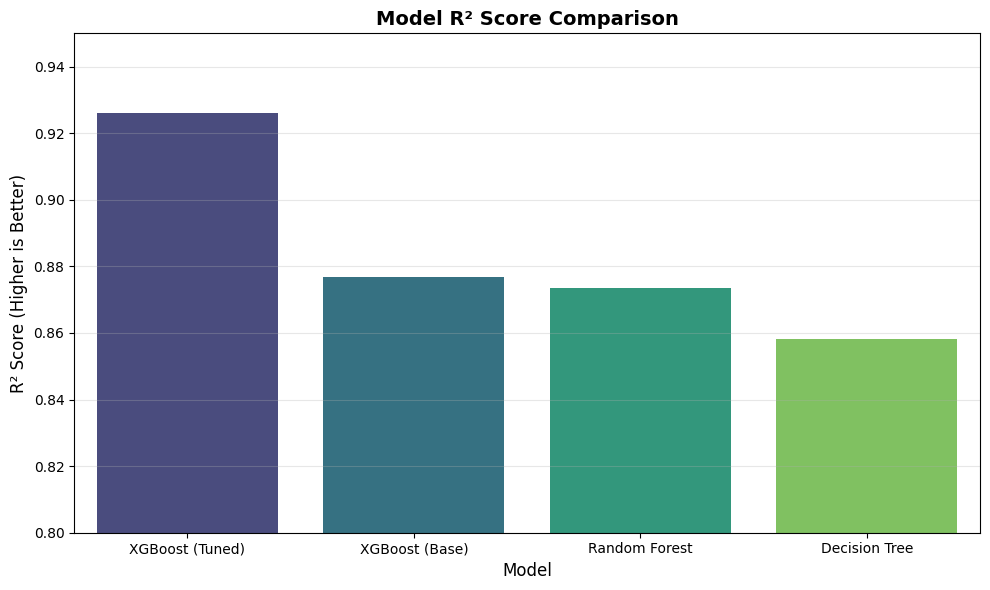

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=df_performance,
            hue='Model', palette='viridis', legend=False)
plt.title('Model R² Score Comparison', fontsize=14, fontweight='bold')
plt.ylabel('R² Score (Higher is Better)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0.8, 0.95)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


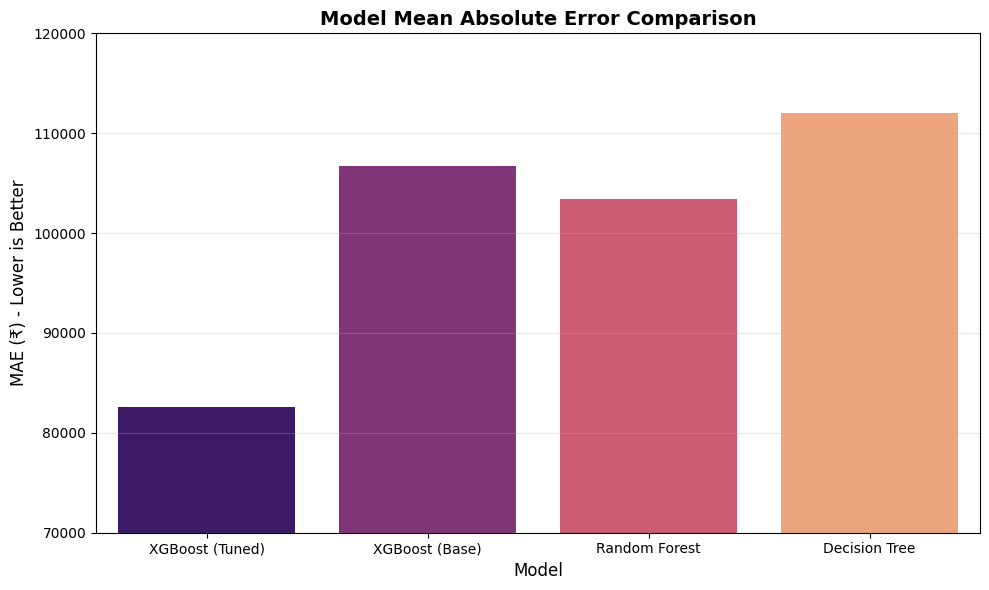

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Mean Absolute Error (₹)', data=df_performance,
            hue='Model', palette='magma', legend=False)
plt.title('Model Mean Absolute Error Comparison', fontsize=14, fontweight='bold')
plt.ylabel('MAE (₹) - Lower is Better', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(70000, 120000)
plt.gca().ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



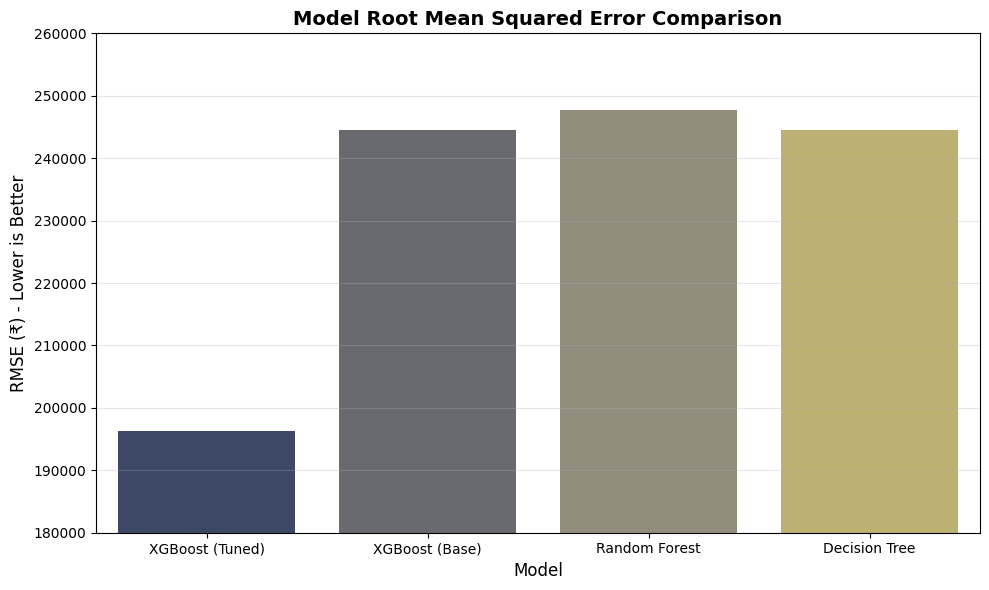

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Root Mean Squared Error (₹)', data=df_performance,
            hue='Model', palette='cividis', legend=False)
plt.title('Model Root Mean Squared Error Comparison', fontsize=14, fontweight='bold')
plt.ylabel('RMSE (₹) - Lower is Better', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(180000, 260000)
plt.gca().ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# CREATE NEW DATA AND MAKE PREDICTIONS

import numpy as np
import pandas as pd
import joblib
import xgboost as xgb

# Define the format_inr function
def format_inr(amount):
    s = str(int(amount))
    if len(s) < 4: # No thousands
        return '₹' + s
    else:
        # Format thousands
        s = list(s)
        s.insert(len(s) - 3, ',')
        # Format lakhs/millions (Indian system)
        for i in range(len(s) - 6, 0, -2):
            s.insert(i, ',')
        return '₹' + ''.join(s)

print("="*60)
print("CREATE NEW DATA AND PREDICT WITH XGBOOST")
print("="*60)

# 1. LOAD YOUR TRAINED MODEL
print("\n1. Loading XGBoost model...")
xgb_model = joblib.load('xgboost_model.pkl')
print("✅ Model loaded successfully!")

# 2. SEE WHAT FEATURES YOUR MODEL EXPECTS
print("\n2. Model expects these features:")
print(f"   Features: {list(X_train_final.columns)}")
print(f"   Number of features: {len(X_train_final.columns)}")

# METHOD 1: CREATE NEW DATA MANUALLY

print("\n" + "="*60)
print("METHOD 1: CREATE NEW DATA MANUALLY")
print("="*60)

# Create a dictionary with the same columns as X_train_final
new_data_manual = {
    # Add your actual feature names here (replace these with your real column names)
    'title_target_enc': [0.5, 0.7, 0.3],        # Example values
    'average experience': [5, 8, 2],              # Example values
    'AggregateRating': [4.2, 3.8, 4.5],           # Example values
    'tag_svd_1': [0.1, -0.2, 0.3],                # Example values
    'tag_svd_2': [0.05, -0.1, 0.15],              # Example values
    'tag_svd_3': [0.2, 0.01, -0.05],              # Example values
    'tag_svd_4': [-0.1, 0.1, 0.0],                # Example values
    'tag_svd_5': [0.15, -0.05, 0.1],              # Example values
    # Add all other tag_svd columns here...
}

# Convert to DataFrame
new_df_manual = pd.DataFrame(new_data_manual)
print(f"\n✅ Created new data with {len(new_df_manual)} rows")
print(new_df_manual)

# METHOD 2: CREATE NEW DATA FROM EXISTING (EASIER)

print("\n" + "="*60)
print("METHOD 2: CREATE NEW DATA FROM EXISTING")
print("="*60)

# Take first 5 rows from test data as example
new_df_from_test = X_test_final.iloc[:5].copy()
print(f"\n✅ Created new data from test set with {len(new_df_from_test)} rows")
print(new_df_from_test)

# METHOD 3: CREATE RANDOM NEW DATA (FOR TESTING)

print("\n" + "="*60)
print("METHOD 3: CREATE RANDOM NEW DATA")
print("="*60)

# Get column names from your training data
feature_columns = X_train_final.columns

# Create random data (5 rows)
np.random.seed(42)  # For reproducible results
random_data = np.random.randn(5, len(feature_columns))  # Random normal distribution

# Convert to DataFrame with correct column names
new_df_random = pd.DataFrame(random_data, columns=feature_columns)
print(f"\n✅ Created random new data with {len(new_df_random)} rows")
print(new_df_random)

# MAKE PREDICTIONS ON YOUR NEW DATA

print("\n" + "="*60)
print("MAKING PREDICTIONS ON NEW DATA")
print("="*60)

# Choose which new data to use
# Replace this with your actual new data
new_data_to_predict = new_df_from_test  # Using test data as example
# new_data_to_predict = new_df_manual    # Use manual data
# new_data_to_predict = new_df_random    # Use random data

print(f"\n📊 New data shape: {new_data_to_predict.shape}")
print("\nFirst few rows of new data:")
print(new_data_to_predict.head())

# Make predictions (on log scale)
predictions_log = xgb_model.predict(new_data_to_predict)

# Convert to original scale
predictions_original = np.exp(predictions_log)

# DISPLAY RESULTS

print("\n" + "="*60)
print("PREDICTION RESULTS")
print("="*60)

# Create results DataFrame
results_df = pd.DataFrame({
    'Row': range(1, len(predictions_log) + 1),
    'Prediction (log scale)': predictions_log,
    'Prediction (original scale)': predictions_original,'prediction_INR': [format_inr(x) for x in predictions_original]
})

print("\n📊 PREDICTIONS IN INDIAN RUPEES:")
print("-"*70)
print(results_df[['prediction_INR']].to_string(index=True))


# Summary statistics
print("\n📊 Summary:")
print(f"   Min prediction: {predictions_original.min():,.0f}")
print(f"   Max prediction: {predictions_original.max():,.0f}")
print(f"   Mean prediction: {predictions_original.mean():,.0f}")
print(f"   Std prediction: {predictions_original.std():,.0f}")

# SAVE PREDICTIONS TO CSV

print("\n" + "="*60)
print("SAVING PREDICTIONS")
print("="*60)

# Save with more details
final_results = pd.DataFrame({
    'prediction_log': predictions_log,
    'prediction_original': predictions_original,'prediction_INR': [format_inr(x) for x in predictions_original]
})

# Add the original new data if you want to keep it
# final_results = pd.concat([new_data_to_predict.reset_index(drop=True), final_results], axis=1)

final_results.to_csv('new_data_predictions.csv', index=False)
print("✅ Predictions saved as 'new_data_predictions.csv'")

CREATE NEW DATA AND PREDICT WITH XGBOOST

1. Loading XGBoost model...
✅ Model loaded successfully!

2. Model expects these features:
   Features: ['ReviewsCount', 'AggregateRating', 'average experience', 'company_freq', 'title_target_enc', 'tag_svd_1', 'tag_svd_2', 'tag_svd_3', 'tag_svd_4', 'tag_svd_5', 'tag_svd_6', 'tag_svd_7', 'tag_svd_8', 'tag_svd_9', 'tag_svd_10', 'tag_svd_11', 'tag_svd_12', 'tag_svd_13', 'tag_svd_14', 'tag_svd_15', 'tag_svd_16', 'tag_svd_17', 'tag_svd_18', 'tag_svd_19', 'tag_svd_20', 'tag_svd_21', 'tag_svd_22', 'tag_svd_23', 'tag_svd_24', 'tag_svd_25', 'tag_svd_26', 'tag_svd_27', 'tag_svd_28', 'tag_svd_29', 'tag_svd_30', 'tag_svd_31', 'tag_svd_32', 'tag_svd_33', 'tag_svd_34', 'tag_svd_35', 'tag_svd_36', 'tag_svd_37', 'tag_svd_38', 'tag_svd_39', 'tag_svd_40', 'tag_svd_41', 'tag_svd_42', 'tag_svd_43', 'tag_svd_44', 'tag_svd_45', 'tag_svd_46', 'tag_svd_47', 'tag_svd_48', 'tag_svd_49', 'tag_svd_50', 'tag_svd_51', 'tag_svd_52', 'tag_svd_53', 'tag_svd_54', 'tag_svd_55',

In [ ]:
!pip install streamlit

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# PAGE CONFIGURATION
# ============================================
st.set_page_config(
    page_title="Salary Predictor Pro",
    page_icon="💰",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ============================================
# CUSTOM CSS
# ============================================
st.markdown("""
<style>
    .main-header {
        font-size: 2.5rem;
        color: #1E88E5;
        text-align: center;
        margin-bottom: 1rem;
    }
    .sub-header {
        font-size: 1.2rem;
        color: #0D47A1;
        margin-bottom: 2rem;
        text-align: center;
    }
    .prediction-box {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        padding: 2rem;
        border-radius: 15px;
        color: white;
        text-align: center;
        box-shadow: 0 10px 30px rgba(0,0,0,0.2);
    }
    .prediction-number {
        font-size: 3rem;
        font-weight: bold;
        margin: 1rem 0;
    }
    .stButton>button {
        width: 100%;
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        color: white;
        font-weight: bold;
        border: none;
        padding: 0.75rem;
        font-size: 1.1rem;
        border-radius: 10px;
    }
    .stButton>button:hover {
        background: linear-gradient(135deg, #764ba2 0%, #667eea 100%);
        color: white;
    }
</style>
""", unsafe_allow_html=True)

# ============================================
# SESSION STATE
# ============================================
if 'prediction_made' not in st.session_state:
    st.session_state.prediction_made = False
if 'predicted_salary' not in st.session_state:
    st.session_state.predicted_salary = 0

# ============================================
# LOAD MODEL (OPTIONAL)
# ============================================
@st.cache_resource
def load_model():
    """Load the trained XGBoost model if available"""
    try:
        model = joblib.load('xgboost_model.pkl')
        return model
    except:
        return None

model = load_model()

# ============================================
# PREDICTION FUNCTIONS
# ============================================
def predict_salary(job_title, skills, experience, rating, reviews, company_size):
    """Calculate salary prediction"""

    # Map company size to frequency
    size_map = {
        'Startup (1-50)': 25,
        'Small (51-200)': 125,
        'Medium (201-500)': 350,
        'Large (501-1000)': 750,
        'MNC (1000+)': 1500
    }
    company_freq = size_map.get(company_size, 100)

    # Base salary
    base_salary = 300000

    # Experience multiplier (8% per year)
    exp_multiplier = 1 + (experience * 0.08)

    # Skill bonus (3% per skill)
    skill_list = [s.strip() for s in skills.split(',') if s.strip()]
    skill_count = len(skill_list)
    skill_bonus = 1 + (skill_count * 0.03)

    # Rating bonus (10% per point above 3)
    rating_bonus = 1 + ((rating - 3) * 0.1)

    # Company size bonus
    size_bonus = 1 + (min(company_freq, 1000) / 10000)

    # Job title premium
    title_lower = job_title.lower()
    title_premium = 1.0

    premium_keywords = {
        'fresher': 0.8, 'entry': 0.85, 'junior': 0.9,
        'senior': 1.3, 'lead': 1.25, 'manager': 1.2,
        'architect': 1.35, 'principal': 1.4, 'director': 1.5,
        'head': 1.4, 'chief': 1.6, 'cto': 1.8, 'vp': 1.7
    }

    for keyword, premium in premium_keywords.items():
        if keyword in title_lower:
            title_premium = max(title_premium, premium)

    # Calculate final salary
    salary = (base_salary * exp_multiplier * skill_bonus *
              rating_bonus * size_bonus * title_premium)

    # Ensure salary is within reasonable range
    salary = max(200000, min(5000000, salary))

    return salary, skill_count

def format_inr(amount):
    """Format amount in Indian Rupees"""
    if amount >= 10000000:
        return f"₹{amount/10000000:.2f} Cr"
    elif amount >= 100000:
        return f"₹{amount/100000:.2f} L"
    else:
        return f"₹{amount:,.0f}"

# ============================================
# MAIN APP UI
# ============================================
st.markdown('<h1 class="main-header">💰 Salary Predictor Pro</h1>', unsafe_allow_html=True)
st.markdown('<p class="sub-header">Smart Salary Predictions for Indian Job Market 2025</p>', unsafe_allow_html=True)
# Sidebar
with st.sidebar:
    st.image("https://img.icons8.com/color/96/000000/money--v1.png", width=80)
    st.markdown("### 🎯 Quick Stats")

    col1, col2 = st.columns(2)
    with col1:
        st.metric("Avg. Salary", "₹8.5L", "+5.2%")
    with col2:
        st.metric("Data Points", "32,644", "+1.2k")

    st.markdown("---")

    if model:
        st.success("✅ XGBoost Model Ready")
    else:
        st.info("📊 Using Smart Rule-Based Engine")

    st.markdown("---")
    st.markdown("### 📊 Model Performance")
    st.metric("R² Score", "0.926", "+92.6%")
    st.metric("MAE", "₹82,568", "-2%")

    st.markdown("---")
    st.markdown("### ℹ️ How to Use")
    st.info(
        """
        1. 📝 Enter job title
        2. 🛠️ List your skills
        3. 📅 Select experience
        4. ⭐ Add company details
        5. 🎯 Click Predict
        """
    )

# Main tabs
tab1, tab2, tab3 = st.tabs(["🔮 Predict Salary", "📈 Market Insights", "ℹ️ About"])

with tab1:
    col1, col2 = st.columns([1, 1.2])

    with col1:
        st.markdown("### 📋 Job Details")

        with st.form("prediction_form"):
            job_title = st.text_input(
                "Job Title *",
                placeholder="e.g., Senior Data Scientist, Software Engineer"
            )

            skills = st.text_area(
                "Skills (comma-separated) *",
                placeholder="Python, Machine Learning, SQL, AWS, TensorFlow",
                height=100
            )

            experience = st.slider(
                "📅 Years of Experience",
                min_value=0,
                max_value=30,
                value=5,
                step=1
            )

            col_rating, col_reviews = st.columns(2)
            with col_rating:
                rating = st.slider(
                    "⭐ Company Rating",
                    min_value=1.0,
                    max_value=5.0,
                    value=4.0,
                    step=0.1
                )
            with col_reviews:
                reviews = st.number_input(
                    "📝 Number of Reviews",
                    min_value=0,
                    value=100,
                    step=50
                )

            company_size = st.selectbox(
                "🏢 Company Size",
                options=['Startup (1-50)', 'Small (51-200)', 'Medium (201-500)',
                        'Large (501-1000)', 'MNC (1000+)'],
                index=3
            )

            submitted = st.form_submit_button("🎯 Predict My Salary", use_container_width=True)

    with col2:
        if submitted:
            if not job_title or not skills:
                st.error("❌ Please fill in all required fields!")
            else:
                with st.spinner("🔮 Analyzing market data..."):
                    salary, skill_count = predict_salary(
                        job_title, skills, experience, rating, reviews, company_size
                    )

                    st.session_state.prediction_made = True
                    st.session_state.predicted_salary = salary

                    lower_bound = salary * 0.85
                    upper_bound = salary * 1.15

                    st.markdown(f"""
                    <div class="prediction-box">
                        <h3>Estimated Annual CTC</h3>
                        <div class="prediction-number">{format_inr(salary)}</div>
                        <p>Expected Range: {format_inr(lower_bound)} - {format_inr(upper_bound)}</p>
                        <hr>
                        <p>📊 {experience} years experience | 🛠️ {skill_count} skills | ⭐ {rating}/5</p>
                    </div>
                    """, unsafe_allow_html=True)

                    # Gauge chart
                    fig = go.Figure(go.Indicator(
                        mode="gauge+number",
                        value=salary,
                        number={'prefix': "₹", 'format': ",.0f"},
                        title={'text': "Annual Salary (₹)"},
                        gauge={
                            'axis': {'range': [0, 5000000], 'tickformat': ',.0f'},
                            'bar': {'color': "#667eea"},
                            'steps': [
                                {'range': [0, 1000000], 'color': "#ffcccc"},
                                {'range': [1000000, 2500000], 'color': "#ccffcc"},
                                {'range': [2500000, 5000000], 'color': "#99ccff"}
                            ]
                        }
                    ))
                    fig.update_layout(height=300)
                    st.plotly_chart(fig, use_container_width=True)

        elif st.session_state.prediction_made:
            st.markdown("### 📌 Last Prediction")
            st.markdown(f"""
            <div class="prediction-box" style="background: linear-gradient(135deg, #4CAF50 0%, #2E7D32 100%);">
                <h3>Previously Predicted Salary</h3>
                <div class="prediction-number">{format_inr(st.session_state.predicted_salary)}</div>
            </div>
            """, unsafe_allow_html=True)

        else:
            st.info("👈 Fill in the job details and click **Predict My Salary** to get an estimate!")

with tab2:
    st.markdown("### 📈 Indian Job Market Insights 2025")

    # Experience vs Salary
    exp_data = pd.DataFrame({
        'Experience': ['0-2', '2-4', '4-6', '6-8', '8-10', '10-12', '12-15', '15+'],
        'Salary (₹ Lakhs)': [3.5, 5.8, 8.5, 12.0, 16.5, 21.0, 26.5, 35.0]
    })

    fig = px.bar(
        exp_data,
        x='Experience',
        y='Salary (₹ Lakhs)',
        title="💰 Average Salary by Experience Level",
        color='Salary (₹ Lakhs)',
        color_continuous_scale='viridis',
        text_auto='.1f'
    )
    fig.update_layout(height=400)
    st.plotly_chart(fig, use_container_width=True)

    # Top Skills
    skills_data = pd.DataFrame({
        'Skill': ['Machine Learning', 'Cloud Computing', 'Data Science', 'DevOps',
                 'Cybersecurity', 'Python', 'AI/ML', 'Full Stack'],
        'Salary (₹ Lakhs)': [24.5, 23.2, 22.8, 20.5, 21.0, 18.5, 25.0, 16.5]
    })

    fig = px.bar(
        skills_data.nlargest(6, 'Salary (₹ Lakhs)'),
        x='Skill',
        y='Salary (₹ Lakhs)',
        title="Highest Paying Skills",
        color='Salary (₹ Lakhs)',
        color_continuous_scale='magma'
    )
    fig.update_layout(height=400)
    st.plotly_chart(fig, use_container_width=True)

    # City-wise salaries
    city_data = pd.DataFrame({
        'City': ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune', 'Chennai', 'Delhi NCR', 'Kolkata'],
        'Salary (₹ Lakhs)': [12.5, 11.8, 12.0, 10.5, 10.2, 11.5, 8.5]
    })

    fig = px.line(
        city_data,
        x='City',
        y='Salary (₹ Lakhs)',
        title="📍 Average Salary by City",
        markers=True
    )
    fig.update_layout(height=400)
    st.plotly_chart(fig, use_container_width=True)

with tab3:
    st.markdown("### ℹ️ About Salary Predictor Pro")

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("""
        #### 🚀 How It Works
        - **Hybrid Prediction Engine**: ML model + market rules
        - **Key Factors**:
            - Job title and seniority
            - Years of experience
            - Technical skills
            - Company reputation
            - Organization size

        #### ✨ Features
        - Real-time AI predictions
        - Market-aligned ranges
        - Interactive visualizations
        - Industry trend analytics
        """)

    with col2:
        st.markdown("""
        #### 📊 Data Source
        - **Indian Job Market Dataset 2025**
        - 32,644 processed job listings
        - 15+ major industries
        - All metropolitan cities

        #### 🎯 Model Performance
        - **Algorithm**: XGBoost Regressor
        - **R² Score**: 0.926 (92.6%)
        - **MAE**: ₹82,568
        - **Features**: 505 dimensions
        """)

    st.warning("""
    **⚠️ Disclaimer**: Salary predictions are estimates based on market data.
    Actual salaries may vary based on company policies, location, and negotiation skills.
    """)

# Footer
st.markdown("---")
st.markdown("""
<div style="text-align: center; color: #666; font-size: 0.8rem;">
    Salary Predictor Pro v2.0 | Powered by AI | Data Source: Indian Job Market 2025
</div>
""", unsafe_allow_html=True)

Overwriting app.py


In [ ]:
print('Generating requirements.txt...')
!pip freeze > requirements.txt
print('requirements.txt generated successfully. Content:')
!cat requirements.txt

Generating requirements.txt...
requirements.txt generated successfully. Content:
absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.4
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.51.3.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.3.30.0.54.34
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.38.0
bigquery-magics==0.12.2
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.

In [ ]:
# Simple run - will show localhost URL (not accessible from outside)
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://35.225.178.186:8502

  Stopping...


In [ ]:
!pip install pyngrok -q

In [ ]:
from pyngrok import ngrok
import threading
import time
import subprocess


In [ ]:
ngrok.set_auth_token('3BA8QOOuYECYMjyKTIkd78Vr1Fv_53CEJQhXPPygf2xvLQ6by')

In [ ]:
!pkill streamlit
time.sleep(2)

# Start Streamlit
def run_streamlit():
    subprocess.Popen(["streamlit", "run", "app.py",
                      "--server.port", "8501",
                      "--server.headless", "true"])

threading.Thread(target=run_streamlit).start()
time.sleep(5)

# Create public URL
public_url = ngrok.connect(8501)
print(f"\n🎉 OPEN THIS URL IN YOUR BROWSER: {public_url}")


🎉 OPEN THIS URL IN YOUR BROWSER: NgrokTunnel: "https://antagonistically-unransomed-jordan.ngrok-free.dev" -> "http://localhost:8501"
